# Slerp: Interpolación Esférica Lineal

**Autor:** Julian Andres Gomez Niño  
**Programa:** Computación Visual  
**Institución:** Universidad Nacional de Colombia

---

In [1]:
import importlib.util
import subprocess
import sys

In [2]:
missing = [
    pkg
    for pkg in ("manim", "numpy", "scipy", "matplotlib", "imageio_ffmpeg")
    if importlib.util.find_spec(pkg) is None
]
if missing:
    packages = {
        "manim": "manim",
        "numpy": "numpy",
        "scipy": "scipy",
        "matplotlib": "matplotlib",
        "imageio_ffmpeg": "imageio-ffmpeg",
    }
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        *[packages[pkg] for pkg in missing],
    ]
    print("Instalando: " + ", ".join(missing))
    print("Comando: " + " ".join(command))
    subprocess.check_call(command)

from pathlib import Path
import numpy as np
import scipy
import scipy.spatial.transform as st
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Video, HTML

In [3]:
from manim import config

config.pixel_height = 480          # 480p
config.pixel_width = 854           # 16:9
config.frame_rate = 15             # fps bajo para velocidad
config.media_dir = "media"         # carpeta de salida
config.preview = False             # no abrir ventana externa
config.write_to_movie = True
config.disable_caching = True

In [4]:
BLUE = "#2a78d6"
YELLOW = "#eda100"
GREEN = "#1baf7a"
RED = "#e34948"
WHITE = "#ffffff"

In [5]:
import shutil

plt.style.use("dark_background")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelcolor": "#c3c2b7",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "text.color": "#ffffff",
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#0d0d0d",
})

def encontrar_video(nombre_escena):
    """Encuentra el MP4 generado por Manim en cualquier calidad."""
    base = Path("media") / "videos"
    nombres = {nombre_escena, f"{nombre_escena}.mp4"}
    matches = sorted(
        path for path in base.rglob("*.mp4")
        if path.name in nombres
    ) if base.exists() else []

    if not matches:
        raise FileNotFoundError(
            f"No se encontró el video de la escena {nombre_escena!r} "
            f"dentro de {base.resolve()}"
        )
    return str(matches[0])

def video_compatible(path):
    """Convierte el MP4 a un formato reproducible en VS Code y Colab."""
    source = Path(path)
    target = source.with_name(f"{source.stem}_browser.mp4")

    if target.exists() and target.stat().st_mtime >= source.stat().st_mtime:
        return str(target)

    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg is None:
        try:
            import imageio_ffmpeg
            ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
        except ImportError as exc:
            raise RuntimeError(
                "No se encontró ffmpeg. En Colab ejecute "
                "!apt-get -qq update && apt-get -qq install -y ffmpeg."
            ) from exc

    command = [
        ffmpeg,
        "-y",
        "-i", str(source),
        "-c:v", "libx264",
        "-profile:v", "baseline",
        "-level", "3.0",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-an",
        str(target),
    ]
    subprocess.run(command, check=True, capture_output=True, text=True)
    return str(target)

def mostrar_video(path):
    """Reproduce un MP4 compatible dentro de VS Code o Google Colab."""
    return Video(
        video_compatible(path),
        embed=True,
        mimetype="video/mp4",
        html_attributes="controls playsinline width=520",
    )

print("Entorno listo.")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
try:
    import manim
    print(f"manim: {manim.__version__}")
except Exception as exc:
    print(f"manim: no disponible ({exc})")

Entorno listo.
Python: 3.13.7
NumPy: 2.3.3
SciPy: 1.18.1
Matplotlib: 3.10.6
manim: 0.21.0


## 1. Motivación

**¿Por qué la interpolación lineal (lerp) falla para rotaciones?**

Imagina dos orientaciones representadas como puntos en una esfera: $S^3$ para cuaterniones unitarios y $S^2$ para ejes-ángulo.

Si interpolamos linealmente entre ellos (lerp), los puntos intermedios caen dentro de la esfera (norma menor que 1). Al renormalizar (nlerp) forzamos la norma a 1, pero la **velocidad angular no es constante**: el punto se mueve más rápido cerca de los extremos y más lento en el medio.

<hr />

En la siguiente animación vemos esto en 2D (círculo unitario $S^1$) y en 3D (Esfera unitaria $S^2$): el punto rojo (lerp) se hunde dentro del círculo, mientras el verde (slerp) se mantiene en el arco y avanza a velocidad constante.


In [6]:
from manim import *


class LerpVsNlerpVsSlerpS1(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        title = Text("Lerp vs. Nlerp vs. Slerp en el círculo unitario", font_size=26)
        title.to_edge(UP)
        self.add(title)

        radius = 2.4
        angle0 = 0.0
        angle1 = np.deg2rad(120)
        q0 = np.array([np.cos(angle0), np.sin(angle0), 0.0])
        q1 = np.array([np.cos(angle1), np.sin(angle1), 0.0])

        circle = Circle(radius=radius, color=WHITE, stroke_width=2)
        self.add(circle)

        dot_q0 = Dot(point=radius * q0, color=BLUE, radius=0.10)
        dot_q1 = Dot(point=radius * q1, color=YELLOW, radius=0.10)
        label_q0 = MathTex("q_0").next_to(dot_q0, LEFT + DOWN, buff=0.12)
        label_q1 = MathTex("q_1").next_to(dot_q1, RIGHT + UP, buff=0.12)
        self.add(dot_q0, dot_q1, label_q0, label_q1)

        arc = Arc(start_angle=angle0, angle=angle1, radius=radius,
                  color=GREEN, stroke_width=4)
        chord = Line(radius * q0, radius * q1, color=RED,
                     stroke_width=2, stroke_opacity=0.65)
        self.add(chord, arc)

        tracker = ValueTracker(0.0)
        omega = angle1 - angle0

        def lerp_vec():
            t = tracker.get_value()
            return (1 - t) * q0 + t * q1

        def lerp_position():
            return radius * lerp_vec()

        def nlerp_position():
            v = lerp_vec()
            return radius * v / np.linalg.norm(v)

        def slerp_position():
            theta = tracker.get_value() * omega
            return radius * np.array([np.cos(theta), np.sin(theta), 0.0])

        # --- Puntos animados ---
        lerp_dot = Dot(color=RED, radius=0.11)
        nlerp_dot = Dot(color=ORANGE, radius=0.11)
        slerp_dot = Dot(color=GREEN, radius=0.11)

        lerp_dot.add_updater(lambda m: m.move_to(lerp_position()))
        nlerp_dot.add_updater(lambda m: m.move_to(nlerp_position()))
        slerp_dot.add_updater(lambda m: m.move_to(slerp_position()))

        self.add(lerp_dot, nlerp_dot, slerp_dot)

        # --- Etiquetas que siguen a los puntos ---
        lerp_label = MathTex(r"\text{lerp}", color=RED)
        nlerp_label = MathTex(r"\text{nlerp}", color=ORANGE)
        slerp_label = MathTex(r"\text{slerp}", color=GREEN)

        lerp_label.add_updater(lambda m: m.next_to(lerp_dot, DOWN, buff=0.10))
        nlerp_label.add_updater(lambda m: m.next_to(nlerp_dot, LEFT, buff=0.12))
        slerp_label.add_updater(lambda m: m.next_to(slerp_dot, UP, buff=0.12))
        self.add(lerp_label, nlerp_label, slerp_label)

        # --- Panel de normas: solo el lerp cae por debajo de 1 ---
        norm_label = MathTex(r"\lVert q_{\mathrm{lerp}}(t) \rVert =")
        norm_value = DecimalNumber(1.0, num_decimal_places=3, color=RED)
        norm_group = VGroup(norm_label, norm_value).arrange(RIGHT, buff=0.12)
        norm_group.to_corner(UL).shift(DOWN * 0.55)
        norm_value.add_updater(lambda m: m.set_value(np.linalg.norm(lerp_vec())))
        self.add(norm_group)

        # --- Leyenda ---
        legend = VGroup(
            MathTex(r"\text{lerp}", color=RED),
            MathTex(r"\text{nlerp}", color=ORANGE),
            MathTex(r"\text{slerp}", color=GREEN),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.55)
        self.add(legend)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=5, rate_func=linear)
        self.wait(0.5)

In [7]:
config.output_file = "LerpVsNlerpVsSlerpS1.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = LerpVsNlerpVsSlerpS1()
scene.render()
mostrar_video(encontrar_video("LerpVsNlerpVsSlerpS1"))

[09/23/26 15:00:20] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS1\uncached_00000.mp4'                                    

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:00:27] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS1\uncached_00001.mp4'                                    

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS1\uncached_00002.mp4'                                    

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian                                                        
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\LerpVsNle                          
                             rpVsSlerpS1.mp4'                                                                      
                                                                                                                   

                    INFO     Rendered LerpVsNlerpVsSlerpS1                                             scene.py:290
                             Played 3 animations                                                                   

In [8]:
from manim import *


class LerpVsNlerpVsSlerpS2(ThreeDScene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        self.set_camera_orientation(phi=75 * DEGREES, theta=-60 * DEGREES)

        title = Text("Lerp vs. Nlerp vs. Slerp en S²", font_size=28)
        title.to_edge(UP)
        self.add_fixed_in_frame_mobjects(title)

        radius = 2.4
        angle0 = 0.0
        angle1 = np.deg2rad(120)
        q0 = np.array([np.cos(angle0), 0.0, np.sin(angle0)])
        q1 = np.array([np.cos(angle1), 0.0, np.sin(angle1)])

        # --- Esfera translúcida con wireframe ---
        sphere = Sphere(radius=radius, resolution=(24, 48))
        sphere.set_fill(color=BLUE_E, opacity=0.12)
        sphere.set_stroke(color=WHITE, width=0.4, opacity=0.20)
        self.add(sphere)

        # --- Puntos extremos q0 y q1 ---
        dot_q0 = Dot3D(point=radius * q0, color=BLUE, radius=0.10)
        dot_q1 = Dot3D(point=radius * q1, color=YELLOW, radius=0.10)
        self.add(dot_q0, dot_q1)

        label_q0 = MathTex("q_0", color=BLUE)
        label_q1 = MathTex("q_1", color=YELLOW)
        label_q0.move_to(1.20 * radius * q0)
        label_q1.move_to(1.20 * radius * q1)
        self.add_fixed_orientation_mobjects(label_q0, label_q1)
        self.add(label_q0, label_q1)

        omega = angle1 - angle0

        # --- Arco geodésico (slerp) sobre la esfera ---
        arc = ParametricFunction(
            lambda s: radius * np.array([
                np.cos(angle0 + s * omega),
                0.0,
                np.sin(angle0 + s * omega),
            ]),
            t_range=[0, 1],
            color=GREEN,
            stroke_width=4,
        )
        self.add(arc)

        # --- Cuerda (lerp) dentro de la esfera ---
        chord = Line3D(radius * q0, radius * q1, color=RED, thickness=0.025)
        chord.set_opacity(0.7)
        self.add(chord)

        # --- Tracker y funciones de posición ---
        tracker = ValueTracker(0.0)

        def lerp_vec():
            t = tracker.get_value()
            return (1 - t) * q0 + t * q1

        def lerp_position():
            return radius * lerp_vec()

        def nlerp_position():
            v = lerp_vec()
            return radius * v / np.linalg.norm(v)

        def slerp_position():
            theta = angle0 + tracker.get_value() * omega
            return radius * np.array([np.cos(theta), 0.0, np.sin(theta)])

        # --- Puntos animados ---
        lerp_dot = Dot3D(color=RED, radius=0.12)
        nlerp_dot = Dot3D(color=ORANGE, radius=0.12)
        slerp_dot = Dot3D(color=GREEN, radius=0.12)

        lerp_dot.add_updater(lambda m: m.move_to(lerp_position()))
        nlerp_dot.add_updater(lambda m: m.move_to(nlerp_position()))
        slerp_dot.add_updater(lambda m: m.move_to(slerp_position()))

        self.add(lerp_dot, nlerp_dot, slerp_dot)

        # --- Panel de norma (fijo en frame, reconstruido cada frame) ---
        def build_norm_group():
            label = MathTex(r"\lVert q_{\mathrm{lerp}}(t) \rVert =")
            value = DecimalNumber(
                np.linalg.norm(lerp_vec()),
                num_decimal_places=3,
                color=RED,
            )
            return (
                VGroup(label, value)
                .arrange(RIGHT, buff=0.12)
                .to_corner(UL)
                .shift(DOWN * 0.55)
            )

        norm_group = always_redraw(build_norm_group)
        self.add_fixed_in_frame_mobjects(norm_group)

        # --- Leyenda (fija en frame) ---
        legend = VGroup(
            MathTex(r"\text{lerp}", color=RED),
            MathTex(r"\text{nlerp}", color=ORANGE),
            MathTex(r"\text{slerp}", color=GREEN),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.55)
        self.add_fixed_in_frame_mobjects(legend)

        # --- Animación ---
        self.wait(0.5)
        self.begin_ambient_camera_rotation(rate=0.15)
        self.play(tracker.animate.set_value(1.0), run_time=5, rate_func=linear)
        self.wait(0.5)
        self.stop_ambient_camera_rotation()

In [9]:
config.output_file = "LerpVsNlerpVsSlerpS2.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = LerpVsNlerpVsSlerpS2()
scene.render()
mostrar_video(encontrar_video("LerpVsNlerpVsSlerpS2"))

[09/23/26 15:00:32] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:00:35] INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS2\uncached_00000.mp4'                                    

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:04:18] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS2\uncached_00001.mp4'                                    

[09/23/26 15:04:19] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:04:42] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\LerpVsNlerpVsSlerpS2\uncached_00002.mp4'                                    

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian                                                        
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\LerpVsNle                          
                             rpVsSlerpS2.mp4'                                                                      
                                                                                                                   

                    INFO     Rendered LerpVsNlerpVsSlerpS2                                             scene.py:290
                             Played 3 animations                                                                   

## 2. Desarrollo matemático

### 2.1 Cuaterniones unitarios como puntos en $S^3$

Un cuaternión unitario
$$
q = w + x\mathbf{i} + y\mathbf{j} + z\mathbf{k}
$$
cumple
$$
\lVert q\rVert^2 = w^2 + x^2 + y^2 + z^2 = 1.
$$
Por tanto, vive en la esfera 3-dimensional $S^3 \subset \mathbb{R}^4$.


### 2.2 Planteamiento del problema

Buscamos una función $q(t)$ que satisfaga simultáneamente:

- **Norma unitaria:** $\lVert q(t)\rVert = 1$ para todo $t\in[0,1]$.
- **Velocidad angular constante:** $\frac{d}{dt}\arg q(t)=\text{constante}$.
- **Condiciones de borde:** $q(0)=q_0$ y $q(1)=q_1$.

La respuesta es la interpolación esférica lineal (spherical linear interpolation, slerp). En las celdas siguientes la derivamos desde cero, partiendo de estas tres exigencias.


### 2.3. Derivación de la fórmula de slerp

Sea

$$
\Omega = \arccos(q_0 \cdot q_1)
$$

el ángulo entre $q_0$ y $q_1$ en $S^3$.

Como ambos cuaterniones son unitarios, el plano generado por ellos corta a $S^3$ en un círculo máximo. Trabajemos en una base ortonormal de ese plano:

$$
e_1 = q_0,
$$

$$
e_2 =
\frac{
q_1 - (q_0 \cdot q_1)q_0
}{
\lVert q_1 - (q_0 \cdot q_1)q_0 \rVert
}.
$$

Cualquier punto del arco mayor puede escribirse como

$$
q(t) =
\cos(\theta(t))\,e_1
+
\sin(\theta(t))\,e_2.
$$

La condición de velocidad angular constante impone

$$
\theta(t) = \Omega t.
$$

Sustituyendo $e_1$ y $e_2$, obtenemos

$$
\begin{aligned}
q(t)
&=
\cos(\Omega t)\,q_0
+
\sin(\Omega t)\,
\frac{
q_1 - (q_0 \cdot q_1)q_0
}{
\sin\Omega
}
\\[6pt]
&=
\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0
+
\frac{\sin(t\Omega)}{\sin\Omega}\,q_1.
\end{aligned}
$$

Por tanto, la fórmula de slerp es

$$
\boxed{
\operatorname{slerp}(q_0,q_1;t)
=
\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0
+
\frac{\sin(t\Omega)}{\sin\Omega}\,q_1
}
$$


### 2.4. Verificación de las propiedades exigidas

La fórmula anterior satisface las tres condiciones del planteamiento.

**Norma unitaria.** Como $q(t)$ se expresa mediante una base ortonormal con coeficientes $\cos(\Omega t)$ y $\sin(\Omega t)$,

$$
\lVert q(t) \rVert^2
=
\cos^2(\Omega t)
+
\sin^2(\Omega t)
=
1.
$$

**Velocidad angular constante.** La derivada $\dot q(t)$ es ortogonal a $q(t)$, y su norma es

$$
\lVert \dot q(t) \rVert = \Omega,
$$

independiente de $t$.

**Condiciones de borde.** En los extremos del intervalo se obtiene

$$
q(0)=q_0,
\qquad
q(1)=q_1.
$$


In [15]:
from manim import *

class PlanoGeneradoYDerivacion(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"

        title = Text("Plano generado por q₀ y q₁", font_size=28)
        title.to_edge(UP, buff=0.35)
        self.add(title)

        radius = 2.3
        angle0 = 0.0
        angle1 = np.deg2rad(100)
        omega = angle1 - angle0
        q0 = np.array([np.cos(angle0), np.sin(angle0), 0.0])
        q1 = np.array([np.cos(angle1), np.sin(angle1), 0.0])
        v0 = radius * q0
        v1 = radius * q1

        # Desplazamos el círculo a la izquierda para dejar la derecha libre
        # para la leyenda y evitar que las etiquetas choquen con el borde.
        center = 1.3 * LEFT

        circle = Circle(radius=radius, color=GRAY, stroke_width=2).move_to(center)
        chord = Line(center + v0, center + v1, color=RED,
                     stroke_width=3, stroke_opacity=0.7)
        arc = Arc(start_angle=angle0, angle=omega, radius=radius,
                  color=GREEN, stroke_width=5, arc_center=center)
        self.add(circle, chord, arc)

        dot0 = Dot(point=center + v0, color=BLUE, radius=0.1)
        dot1 = Dot(point=center + v1, color=YELLOW, radius=0.1)
        # q0 apunta a la derecha: etiqueta hacia abajo-derecha, fuera del arco.
        label0 = MathTex("q_0", color=BLUE).next_to(dot0, DR, buff=0.14)
        # q1 arriba: etiqueta hacia arriba-izquierda para no rozar el título.
        label1 = MathTex("q_1", color=YELLOW).next_to(dot1, UL, buff=0.14)
        self.add(dot0, dot1, label0, label1)

        tracker = ValueTracker(0.0)

        def slerp_vec():
            theta = angle0 + tracker.get_value() * omega
            return np.array([np.cos(theta), np.sin(theta), 0.0])

        def slerp_point():
            return center + radius * slerp_vec()

        qt_dot = Dot(point=center + v0, color=WHITE, radius=0.12)
        qt_dot.add_updater(lambda mob: mob.move_to(slerp_point()))
        qt_label = MathTex("q(t)", color=WHITE)
        # La etiqueta sigue al punto en dirección radial (hacia afuera del
        # círculo), así nunca pisa la cuerda, el arco ni las etiquetas fijas.
        qt_label.add_updater(
            lambda mob: mob.move_to(center + (radius + 0.42) * slerp_vec())
        )
        self.add(qt_dot, qt_label)

        # Ω dentro del sector (radio reducido) para no montarse con el arco.
        omega_label = MathTex(r"\Omega").move_to(
            center + 0.65 * radius * np.array(
                [np.cos(omega / 2), np.sin(omega / 2), 0.0]
            )
        )
        legend = VGroup(
            MathTex(r"\text{slerp}", color=GREEN),
            MathTex(r"\text{cuerda}", color=RED),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.12)
        legend.to_corner(UR, buff=0.5)
        self.add(omega_label, legend)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

        qt_dot.clear_updaters()
        qt_label.clear_updaters()

In [17]:
config.output_file = "PlanoGeneradoYDerivacion.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = PlanoGeneradoYDerivacion()
scene.render()
mostrar_video(encontrar_video("PlanoGeneradoYDerivacion"))

[09/23/26 15:52:29] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:52:30] INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion\uncached_00000.mp4'                                

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 15:52:31] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion\uncached_00001.mp4'                                

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion\uncached_00002.mp4'                                

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

[09/23/26 15:52:32] INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian                                                        
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\PlanoGene                          
                             radoYDerivacion.mp4'                                                                  
                                                                                                                   

                    INFO     Rendered PlanoGeneradoYDerivacion                                         scene.py:290
                             Played 3 animations                                                                   

In [20]:
from manim import *

class PlanoGeneradoYDerivacion3d(ThreeDScene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        self.set_camera_orientation(phi=68 * DEGREES, theta=-50 * DEGREES, zoom=1.0)

        # --- Título y leyenda fijos al frame (siempre legibles) --------------
        title = Text("Plano generado por q₀ y q₁", font_size=28)
        title.to_edge(UP, buff=0.3)
        legend = VGroup(
            MathTex(r"\text{slerp (arco)}", color=GREEN, font_size=30),
            MathTex(r"\text{cuerda}", color=RED, font_size=30),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.14)
        legend.to_corner(UR, buff=0.4)
        self.add_fixed_in_frame_mobjects(title, legend)

        # --- Geometría en el espacio ----------------------------------------
        # Dos direcciones unitarias que generan el plano Pi = span{q0, q1}.
        q0 = np.array([1.0, 0.0, 0.0])
        raw = np.array([np.cos(np.deg2rad(100)), np.sin(np.deg2rad(100)), 0.0])
        # Los inclinamos fuera del plano XY para que el corte se vea en 3D.
        R_tilt = self._rot_axis(np.array([1.0, 0.4, 0.0]), np.deg2rad(35))
        q0 = R_tilt @ q0
        q1 = R_tilt @ raw
        q0 /= np.linalg.norm(q0)
        q1 /= np.linalg.norm(q1)

        omega = float(np.arccos(np.clip(np.dot(q0, q1), -1.0, 1.0)))

        # Base ortonormal del plano: e1 = q0, e2 ⟂ e1 dentro de Pi.
        e1 = q0
        e2 = q1 - np.dot(q0, q1) * q0
        e2 /= np.linalg.norm(e2)

        def slerp_vec(t):
            theta = t * omega
            return np.cos(theta) * e1 + np.sin(theta) * e2

        # --- Esfera unitaria S^2 --------------------------------------------
        esfera = Surface(
            lambda u, v: np.array([
                np.cos(u) * np.cos(v),
                np.cos(u) * np.sin(v),
                np.sin(u),
            ]),
            u_range=[-PI / 2, PI / 2], v_range=[0, TAU], resolution=(24, 48),
        )
        esfera.set_style(fill_opacity=0.15, stroke_width=0.6,
                         stroke_opacity=0.25, stroke_color=GRAY)
        esfera.set_fill(color="#2b3a5c")

        ejes = ThreeDAxes(
            x_range=[-1.6, 1.6, 1], y_range=[-1.6, 1.6, 1], z_range=[-1.6, 1.6, 1],
            x_length=4.4, y_length=4.4, z_length=4.4, tips=False,
            axis_config={"color": GRAY, "stroke_width": 1.6, "stroke_opacity": 0.6},
        )
        esc = 4.4 / (2 * 1.6)  # unidad de los ejes en pantalla

        self.play(FadeIn(ejes), FadeIn(esfera), run_time=1.5)

        # --- q0 y q1 como flechas desde el origen ---------------------------
        f0 = Arrow3D(ORIGIN, esc * q0, color=BLUE, thickness=0.02)
        f1 = Arrow3D(ORIGIN, esc * q1, color=YELLOW, thickness=0.02)
        d0 = Dot3D(esc * q0, color=BLUE, radius=0.07)
        d1 = Dot3D(esc * q1, color=YELLOW, radius=0.07)
        lab0 = MathTex("q_0", color=BLUE, font_size=34)
        lab1 = MathTex("q_1", color=YELLOW, font_size=34)
        self.add_fixed_orientation_mobjects(lab0, lab1)
        lab0.add_updater(lambda m: m.move_to(esc * q0 * 1.18))
        lab1.add_updater(lambda m: m.move_to(esc * q1 * 1.18))
        self.play(Create(f0), Create(f1), FadeIn(d0), FadeIn(d1), run_time=1.3)

        # --- Plano que generan y su círculo máximo --------------------------
        M = np.column_stack([e1, e2, np.cross(e1, e2)]) * esc
        plano = Square(side_length=2.6, fill_color=GREEN, fill_opacity=0.12,
                       stroke_color=GREEN, stroke_width=1.5, stroke_opacity=0.5)
        plano.apply_matrix(np.column_stack([e1, e2, np.cross(e1, e2)]))
        circulo = Circle(radius=1.0, color=GREEN, stroke_width=4)
        circulo.apply_matrix(M)
        self.play(FadeIn(plano), run_time=1.2)
        self.play(Create(circulo), run_time=1.4)

        # --- Cuerda recta (lerp) entre q0 y q1 ------------------------------
        cuerda = Line3D(esc * q0, esc * q1, color=RED, thickness=0.015)
        self.play(Create(cuerda), run_time=1.0)

        # --- Arco geodésico + punto q(t) recorriéndolo ----------------------
        arco = ParametricFunction(
            lambda s: esc * slerp_vec(s),
            t_range=[0, 1], color=GREEN, stroke_width=8,
        )
        tracker = ValueTracker(0.0)
        qt_dot = Dot3D(esc * slerp_vec(0.0), color=WHITE, radius=0.09)
        qt_dot.add_updater(lambda m: m.move_to(esc * slerp_vec(tracker.get_value())))
        qt_radio = always_redraw(
            lambda: Line3D(ORIGIN, esc * slerp_vec(tracker.get_value()),
                           color=WHITE, thickness=0.008)
        )
        qt_label = MathTex("q(t)", color=WHITE, font_size=34)
        self.add_fixed_orientation_mobjects(qt_label)
        qt_label.add_updater(
            lambda m: m.move_to(esc * slerp_vec(tracker.get_value()) * 1.22)
        )

        self.add(qt_radio, qt_dot, qt_label)
        self.play(Create(arco), run_time=1.4)

        # Rotación ambiental suave mientras q(t) recorre el arco.
        self.begin_ambient_camera_rotation(rate=0.12)
        self.wait(0.4)
        self.play(tracker.animate.set_value(1.0), run_time=6, rate_func=linear)
        self.wait(1.0)
        self.stop_ambient_camera_rotation()

        qt_dot.clear_updaters()
        qt_label.clear_updaters()
        lab0.clear_updaters()
        lab1.clear_updaters()
        self.wait(0.5)

    @staticmethod
    def _rot_axis(axis, angle):
        """Matriz de rotación (Rodrigues) alrededor de `axis` por `angle`."""
        axis = axis / np.linalg.norm(axis)
        x, y, z = axis
        c, s = np.cos(angle), np.sin(angle)
        C = 1 - c
        return np.array([
            [c + x * x * C,     x * y * C - z * s, x * z * C + y * s],
            [y * x * C + z * s, c + y * y * C,     y * z * C - x * s],
            [z * x * C - y * s, z * y * C + x * s, c + z * z * C],
        ])


In [21]:
config.output_file = "PlanoGeneradoYDerivacion3d.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = PlanoGeneradoYDerivacion3d()
scene.render()
mostrar_video(encontrar_video("PlanoGeneradoYDerivacion3d"))

[09/23/26 15:59:40] INFO     Writing \special{dvisvgm:raw <g id='unique000'>}\text{slerp    tex_file_writing.py:110
                             (arco)}\special{dvisvgm:raw </g>} to                                                  
                             media\Tex\386751f2b52f618d.tex                                                        

[09/23/26 15:59:48] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 16:00:33] INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion3d\uncached_00000.mp4'                              

[09/23/26 16:00:38] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 16:01:28] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion3d\uncached_00001.mp4'                              

...

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 16:14:38] INFO     Animation 9 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\PlanoGeneradoYDerivacion3d\uncached_00009.mp4'                              

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian                                                        
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\PlanoGene                          
                             radoYDerivacion3d.mp4'                                                                
                                                                                                                   

                    INFO     Rendered PlanoGeneradoYDerivacion3d                                       scene.py:290
                             Played 10 animations                                                                  

### 2.5. Verificación de las tres propiedades

Las tres condiciones del planteamiento quedan satisfechas por construcción:

- **Norma unitaria:** se conserva la identidad trigonométrica $\cos^2(\theta)+\sin^2(\theta)=1$.
- **Velocidad angular constante:** $\lVert \dot q(t) \rVert=\Omega$, independiente de $t$.
- **Condiciones de borde:** $q(0)=q_0$ y $q(1)=q_1$.

En consecuencia, `slerp` produce un arco sobre $S^3$ con movimiento angular uniforme.


### 2.6. Caso degenerado $\Omega \to 0$

Cuando $q_0$ y $q_1$ son casi paralelos, se cumple

$$
\Omega \to 0
\qquad\text{y}\qquad
\sin\Omega \approx 0.
$$

En este régimen, la fórmula de `slerp` puede volverse numéricamente inestable. Sin embargo, el arco y la cuerda casi coinciden, por lo que es razonable utilizar `nlerp` —interpolación lineal seguida de renormalización— como caso particular:

$$
\operatorname{slerp}(q_0,q_1;t)
\approx
\operatorname{nlerp}(q_0,q_1;t),
\qquad
\Omega \to 0.
$$


### 2.7. Doble cobertura y corrección

Los cuaterniones $q$ y $-q$ representan la misma rotación. Por ello, el signo absoluto de un cuaternión no tiene significado geométrico.

Si

$$
q_0 \cdot q_1 < 0,
$$

la fórmula seleccionaría inicialmente el arco mayor, superior a $180^\circ$. Para elegir siempre el arco menor, podemos cambiar el signo de $q_1$:

$$
\text{si } q_0 \cdot q_1 < 0,
\qquad
q_1 \leftarrow -q_1.
$$

Esta corrección evita giros largos e inesperados cuando dos orientaciones están cerca en $SO(3)$, pero sus representaciones en $S^3$ se encuentran en hemisferios opuestos.


In [22]:
from manim import *

class VelocidadAngular(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"

        title = Text("Velocidad angular: slerp vs. nlerp", font_size=28)
        title.to_edge(UP, buff=0.35)
        self.add(title)

        omega = np.deg2rad(120)
        cosine = np.cos(omega)

        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 2.4, 0.4],
            x_length=7,
            y_length=4.2,
            axis_config={"color": WHITE, "stroke_width": 1},
            tips=False,
        )
        # Bajamos un poco los ejes para dejar aire bajo el título.
        axes.to_edge(DOWN, buff=0.6)
        axes_labels = axes.get_axis_labels(
            x_label=MathTex("t"),
            y_label=MathTex(r"\theta(t)\ [\mathrm{rad}]"),
        )
        self.add(axes, axes_labels)

        def theta_slerp(t):
            return omega * t

        def theta_nlerp(t):
            numerator = (1 - t) + t * cosine
            denominator = np.sqrt(
                (1 - t) ** 2 + t ** 2 + 2 * t * (1 - t) * cosine
            )
            return np.arccos(np.clip(numerator / denominator, -1, 1))

        slerp_curve = axes.plot(
            theta_slerp, x_range=[0, 1], color=GREEN, stroke_width=3
        )
        nlerp_curve = axes.plot(
            theta_nlerp, x_range=[0, 1], color=RED, stroke_width=3
        )
        self.add(slerp_curve, nlerp_curve)

        tracker = ValueTracker(0.0)
        dot_s = Dot(color=GREEN, radius=0.09)
        dot_n = Dot(color=RED, radius=0.09)

        def update_slerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_slerp(t)))

        def update_nlerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_nlerp(t)))

        dot_s.add_updater(update_slerp_dot)
        dot_n.add_updater(update_nlerp_dot)
        self.add(dot_s, dot_n)

        # Las etiquetas se separan a lados opuestos para que no se crucen
        # cuando ambos puntos coinciden en t = 0 y t = 1.
        label_s = MathTex(r"\text{slerp}", color=GREEN, font_size=32)
        label_n = MathTex(r"\text{nlerp}", color=RED, font_size=32)
        label_s.add_updater(lambda mob: mob.next_to(dot_s, UL, buff=0.12))
        label_n.add_updater(lambda mob: mob.next_to(dot_n, DR, buff=0.12))
        self.add(label_s, label_n)

        # Panel de fórmulas en una zona despejada (arriba-derecha del gráfico),
        # lejos del eje Y y de su etiqueta.
        formulas = VGroup(
            MathTex(r"\theta_{\mathrm{slerp}}(t)=\Omega t", color=GREEN),
            MathTex(
                r"\theta_{\mathrm{nlerp}}(t)=\arccos\!\frac{(1-t)+t\cos\Omega}"
                r"{\lVert(1-t)q_0+t\,q_1\rVert}",
                color=RED,
            ),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.25).scale(0.6)
        formulas.next_to(title, DOWN, buff=0.2).to_edge(RIGHT, buff=0.6)
        self.add(formulas)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

        dot_s.remove_updater(update_slerp_dot)
        dot_n.remove_updater(update_nlerp_dot)
        label_s.clear_updaters()
        label_n.clear_updaters()


In [23]:
config.output_file = "VelocidadAngular.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = VelocidadAngular()
scene.render()
mostrar_video(encontrar_video("VelocidadAngular"))

[09/23/26 16:16:12] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\VelocidadAngular\uncached_00000.mp4'                                        

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 16:16:15] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\VelocidadAngular\uncached_00001.mp4'                                        

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 16:16:16] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\partial_mo                         
                             vie_files\VelocidadAngular\uncached_00002.mp4'                                        

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian                                                        
                             Gomez\Desktop\slerp_kiro\slerp\media\videos\480p15\Velocidad                          
                             Angular.mp4'                                                                          
                                                                                                                   

                    INFO     Rendered VelocidadAngular                                                 scene.py:290
                             Played 3 animations                                                                   

## 3. Aplicación práctica

Ahora pasamos de la teoría a una implementación lista para usar en gráficos por computadora. Construiremos:

- `slerp` desde cero en NumPy, con corrección de doble cobertura y fallback numérico.
- Una validación frente a `scipy.spatial.transform.Slerp`.
- Un benchmark de velocidad angular que compare `slerp` con `nlerp`.
- Una animación 3D de una flecha que interpola dos orientaciones.


### 3.1. Implementación de slerp desde cero en NumPy

La implementación siguiente normaliza primero los cuaterniones de entrada, corrige la doble cobertura y aplica la fórmula analítica de `slerp`.

Cuando los cuaterniones están muy cerca, utiliza `nlerp` como aproximación estable.


In [24]:
"""Interpolación de cuaterniones: slerp y nlerp.

Convención de cuaternión: array de forma (4,) en orden (w, x, y, z).
Ambas funciones aceptan `t` escalar o array de cualquier forma y devuelven
un array de forma (*t.shape, 4).
"""

import numpy as np

def _as_quaternion(q):
    """Valida y normaliza un único cuaternión a norma unitaria."""
    q = np.asarray(q, dtype=float)
    if q.shape != (4,):
        raise ValueError(f"Cada cuaternión debe tener forma (4,); se recibió {q.shape}.")
    norm = np.linalg.norm(q)
    if norm == 0.0:
        raise ValueError("Un cuaternión nulo no se puede normalizar.")
    return q / norm

def _normalize_rows(v):
    """Normaliza a lo largo del último eje, con protección ante norma nula."""
    norm = np.linalg.norm(v, axis=-1, keepdims=True)
    # Evita dividir por cero: donde la norma es 0 dejamos el vector intacto.
    norm = np.where(norm == 0.0, 1.0, norm)
    return v / norm

def nlerp(q0, q1, t):
    """Interpolación lineal normalizada entre dos cuaterniones unitarios.

    Rápida y de norma unitaria, pero con velocidad angular no constante.

    Parameters
    ----------
    q0, q1 : array_like, shape (4,)
    t : float o array_like

    Returns
    -------
    np.ndarray de forma (*np.shape(t), 4).
    """
    q0 = _as_quaternion(q0)
    q1 = _as_quaternion(q1)
    t = np.asarray(t, dtype=float)[..., None]  # (*t.shape, 1)

    # Tomar el camino corto: si el ángulo es obtuso, q ~ -q es la misma rotación.
    if np.dot(q0, q1) < 0.0:
        q1 = -q1

    result = (1.0 - t) * q0 + t * q1
    return _normalize_rows(result)

def slerp(q0, q1, t, epsilon=1e-6):
    """Interpolación esférica lineal entre dos cuaterniones unitarios.

    Recorre el arco geodésico a velocidad angular constante.

    Parameters
    ----------
    q0, q1 : array_like, shape (4,)
    t : float o array_like
    epsilon : float
        Umbral bajo el cual se cae a `nlerp` para evitar división por
        ``sin(omega) ≈ 0`` cuando q0 y q1 son casi colineales.

    Returns
    -------
    np.ndarray de forma (*np.shape(t), 4).
    """
    q0 = _as_quaternion(q0)
    q1 = _as_quaternion(q1)
    t = np.asarray(t, dtype=float)

    dot = float(np.clip(np.dot(q0, q1), -1.0, 1.0))
    if dot < 0.0:  # camino corto: misma rotación con signo opuesto
        q1 = -q1
        dot = -dot

    # Cuaterniones casi colineales: sin(omega) -> 0, la fórmula es inestable.
    if dot > 1.0 - epsilon:
        return nlerp(q0, q1, t)

    omega = np.arccos(dot)
    sin_omega = np.sin(omega)

    t_ = t[..., None]  # (*t.shape, 1) para broadcasting con (4,)
    coeff0 = np.sin((1.0 - t_) * omega) / sin_omega
    coeff1 = np.sin(t_ * omega) / sin_omega
    return coeff0 * q0 + coeff1 * q1


In [25]:
if __name__ == "__main__":
    q0 = [1, 0, 0, 0]
    q1 = [0, 0, 0, 1]  # 180° alrededor del eje z (w=cos(90°)=0, z=sin(90°)=1)

    # Escalar
    print("slerp escalar:")
    for ti in np.linspace(0, 1, 5):
        print(f"  t={ti:.2f} -> {slerp(q0, q1, ti)}")

    # Vectorizado: una sola llamada para todos los t
    ts = np.linspace(0, 1, 5)
    print("\nslerp vectorizado:", slerp(q0, q1, ts).shape)
    print(slerp(q0, q1, ts))

    # Verificación: norma unitaria en todo t
    norms = np.linalg.norm(slerp(q0, q1, ts), axis=-1)
    print("\n||slerp(t)|| =", np.round(norms, 12))


slerp escalar:
  t=0.00 -> [1. 0. 0. 0.]
  t=0.25 -> [0.92387953 0.         0.         0.38268343]
  t=0.50 -> [0.70710678 0.         0.         0.70710678]
  t=0.75 -> [0.38268343 0.         0.         0.92387953]
  t=1.00 -> [0. 0. 0. 1.]

slerp vectorizado: (5, 4)
[[1.         0.         0.         0.        ]
 [0.92387953 0.         0.         0.38268343]
 [0.70710678 0.         0.         0.70710678]
 [0.38268343 0.         0.         0.92387953]
 [0.         0.         0.         1.        ]]

||slerp(t)|| = [1. 1. 1. 1. 1.]


### 3.2. Validación frente a `scipy.spatial.transform.Slerp`

Para comprobar la implementación, generamos cuaterniones unitarios aleatorios y comparamos los resultados con `scipy.spatial.transform.Slerp`.

SciPy utiliza el orden `(x, y, z, w)`, mientras que esta implementación utiliza el orden `(w, x, y, z)`. Por eso, los resultados de SciPy se reordenan antes de calcular el error.


In [27]:
import numpy as np
import scipy.spatial.transform as st

def _angular_distance(a, b):
    dots = np.clip(np.abs(np.sum(a * b, axis=-1)), -1.0, 1.0)
    return 2.0 * np.arccos(dots)

def compare_slerp(num_tests=200, num_t=50, seed=0, tol=1e-6):
    rng = np.random.default_rng(seed)
    t_vals = np.linspace(0.0, 1.0, num_t)

    max_err = 0.0
    worst_case = None

    for _ in range(num_tests):
        q0 = rng.standard_normal(4); q0 /= np.linalg.norm(q0)
        q1 = rng.standard_normal(4); q1 /= np.linalg.norm(q1)
        if np.dot(q0, q1) < 0.0:
            q1 = -q1

        key_rot = st.Rotation.from_quat([q0[[1, 2, 3, 0]], q1[[1, 2, 3, 0]]])
        q_scipy = np.roll(st.Slerp([0.0, 1.0], key_rot)(t_vals).as_quat(),
                          shift=1, axis=1)
        q_ours = slerp(q0, q1, t_vals)

        err = float(np.max(_angular_distance(q_ours, q_scipy)))
        if err > max_err:
            omega = np.arccos(np.clip(np.dot(q0, q1), -1.0, 1.0))
            max_err = err
            worst_case = (q0.copy(), q1.copy(), err, float(omega))

    print(f"Máximo error angular en {num_tests} pruebas: {max_err:.2e} rad")
    if worst_case is not None:
        q0w, q1w, ew, omw = worst_case
        print(f"Peor caso: error {ew:.2e} rad, Ω = {np.degrees(omw):.2f}°")
        print(f"  sin(Ω) = {np.sin(omw):.2e}  (mayor error ⇔ Ω cerca de 180°)")
        print(f"  q0 = {np.round(q0w, 6)}")
        print(f"  q1 = {np.round(q1w, 6)}")

    return max_err

if __name__ == "__main__":
    tol = 1e-6
    err = compare_slerp(num_tests=200, tol=tol)
    assert err < tol, f"Error demasiado grande: {err:.2e} >= {tol:.0e}"
    print("Validación superada.")


Máximo error angular en 200 pruebas: 5.16e-08 rad
Peor caso: error 5.16e-08 rad, Ω = 38.27°
  sin(Ω) = 6.19e-01  (mayor error ⇔ Ω cerca de 180°)
  q0 = [ 0.271368  0.439404 -0.747521 -0.417726]
  q1 = [ 0.19858   0.532265 -0.79142   0.225642]
Validación superada.


### 3.3. Benchmark: variación de velocidad angular

Comparamos ahora la velocidad angular de `slerp` y `nlerp`.

- `slerp` debe mantener una velocidad angular constante.
- `nlerp` conserva la norma, pero puede variar su velocidad angular.

La métrica utilizada es la desviación relativa de las velocidades angulares instantáneas aproximadas.


In [30]:
import numpy as np

def angular_velocity_error(q0, q1, t_vals, method="slerp"):
    r"""Desviación relativa de la velocidad angular a lo largo de la curva.

    Mide la velocidad angular instantánea por diferencias finitas usando el
    ángulo entre cuaterniones consecutivos, ``\Delta\theta_k = \angle(q_k, q_{k+1})``,
    y devuelve su coeficiente de variación ``std/mean``.

    - slerp  -> velocidad angular constante  => error ≈ 0
    - nlerp  -> se acelera en el centro       => error > 0

    Parameters
    ----------
    q0, q1 : array_like, shape (4,)
    t_vals : array_like
        Muestras del parámetro (no necesitan ser equiespaciadas).
    method : {"slerp", "nlerp"}

    Returns
    -------
    rel_error : float
        Coeficiente de variación de la velocidad angular (0 = perfecta).
    thetas : np.ndarray
        Ángulo acumulado recorrido desde q0 en cada muestra.
    omegas : np.ndarray
        Velocidad angular instantánea entre muestras consecutivas.
    """
    if method not in ("slerp", "nlerp"):
        raise ValueError(f"method debe ser 'slerp' o 'nlerp'; se recibió {method!r}.")

    q0 = np.asarray(q0, dtype=float); q0 = q0 / np.linalg.norm(q0)
    q1 = np.asarray(q1, dtype=float); q1 = q1 / np.linalg.norm(q1)
    t_vals = np.asarray(t_vals, dtype=float)
    if t_vals.ndim != 1 or t_vals.size < 2:
        raise ValueError("t_vals debe ser 1-D con al menos 2 muestras.")

    interp = slerp if method == "slerp" else nlerp
    qs = np.atleast_2d(interp(q0, q1, t_vals))  # (N, 4), vectorizado

    # Alinear signos: q y -q son la misma rotación; evita saltos espurios de π
    # entre muestras consecutivas al medir ángulos.
    signs = np.sign(np.sum(qs * qs[0], axis=1))
    signs[signs == 0] = 1.0
    qs = qs * signs[:, None]

    # Ángulo incremental entre cuaterniones consecutivos (robusto en t≈0).
    dots_consec = np.clip(np.sum(qs[:-1] * qs[1:], axis=1), -1.0, 1.0)
    dtheta = np.arccos(dots_consec)                    # (N-1,)
    dt = np.diff(t_vals)                               # (N-1,)
    omegas = dtheta / dt

    # Ángulo acumulado recorrido desde q0 (monótono, sin arccos cerca de 0).
    thetas = np.concatenate([[0.0], np.cumsum(dtheta)])

    mean_omega = np.mean(omegas)
    rel_error = float(np.std(omegas) / mean_omega) if abs(mean_omega) > 1e-12 \
        else float(np.std(omegas))
    return rel_error, thetas, omegas


#### Parámetros de prueba: rotación de 90 grados

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# q1 = 120° alrededor del eje y  (w=cos60°=0.5, y=sin60°≈0.866), orden (w,x,y,z).
# Un ángulo intermedio hace visible el contraste slerp vs nlerp;
# con 180° (antipodal) ambos casi coinciden y el efecto se disimula.
q0 = [1.0, 0.0, 0.0, 0.0]
q1 = [0.5, 0.0, np.sqrt(3) / 2, 0.0]
t_vals = np.linspace(0.0, 1.0, 101)

rel_err_slerp, theta_s, omega_s = angular_velocity_error(q0, q1, t_vals, method="slerp")
rel_err_nlerp, theta_n, omega_n = angular_velocity_error(q0, q1, t_vals, method="nlerp")

print("Desviación relativa de la velocidad angular (coef. de variación):")
print(f"  slerp: {rel_err_slerp:.2e}   (esperado ≈ 0: velocidad constante)")
print(f"  nlerp: {rel_err_nlerp:.2e}   (mayor: se acelera en el centro)")


Desviación relativa de la velocidad angular (coef. de variación):
  slerp: 1.27e-12   (esperado ≈ 0: velocidad constante)
  nlerp: 8.53e-02   (mayor: se acelera en el centro)


#### Gráfica de $\theta$(t)

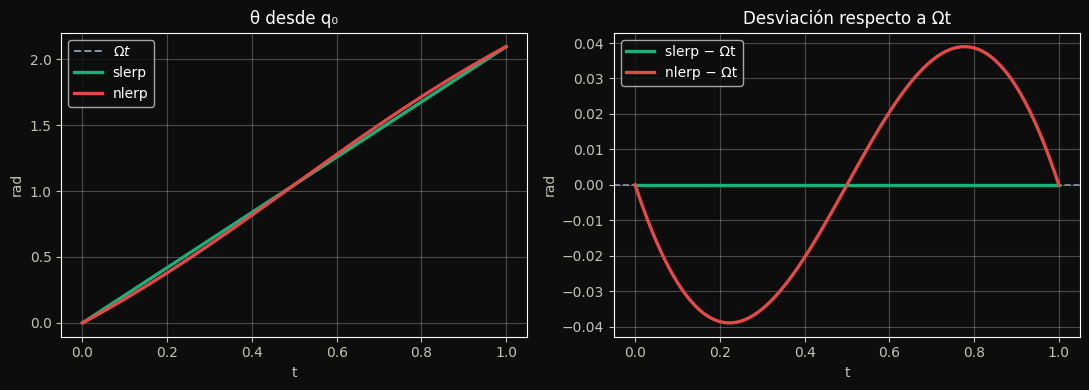

In [36]:
import numpy as np
import matplotlib.pyplot as plt

plot_t = np.linspace(0.0, 1.0, 101)
plot_q0 = [1.0, 0.0, 0.0, 0.0]
plot_q1 = [0.5, 0.0, np.sqrt(3) / 2, 0.0]

def angle_from_q0(method):
    q0 = np.array(plot_q0, float); q0 /= np.linalg.norm(q0)
    q1 = np.array(plot_q1, float); q1 /= np.linalg.norm(q1)
    interp = slerp if method == "slerp" else nlerp
    qs = np.atleast_2d(interp(q0, q1, plot_t))
    return 2.0 * np.arccos(np.clip(np.abs(qs @ q0), -1.0, 1.0))

theta_s, theta_n = angle_from_q0("slerp"), angle_from_q0("nlerp")
Omega = theta_s[-1]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(plot_t, Omega*plot_t, "--", color="#8C94A8", lw=1.4, label=r"$\Omega t$")
a1.plot(plot_t, theta_s, color="#1baf7a", lw=2.4, label="slerp")
a1.plot(plot_t, theta_n, color="#e34948", lw=2.4, label="nlerp")
a1.set_title("θ desde q₀"); a1.set_xlabel("t"); a1.set_ylabel("rad"); a1.legend()

a2.axhline(0, color="#8C94A8", ls="--", lw=1.2)
a2.plot(plot_t, theta_s - Omega*plot_t, color="#1baf7a", lw=2.4, label="slerp − Ωt")
a2.plot(plot_t, theta_n - Omega*plot_t, color="#e34948", lw=2.4, label="nlerp − Ωt")
a2.set_title("Desviación respecto a Ωt"); a2.set_xlabel("t"); a2.set_ylabel("rad"); a2.legend()
fig.tight_layout(); plt.show()


#### Gráfica de velocidad angular instantánea

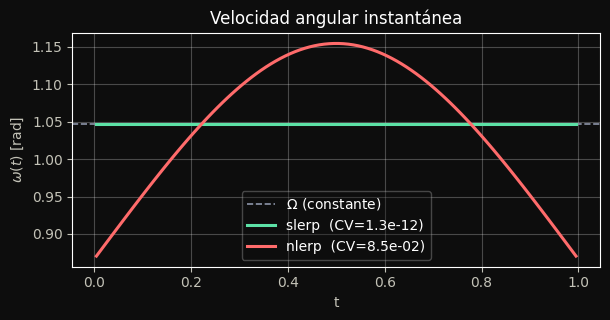

In [38]:
# --- Gráfico de ω(t): la firma visual de la velocidad angular ---------------
t_mid = 0.5 * (t_vals[:-1] + t_vals[1:])   # ω vive entre muestras consecutivas
Omega = np.arccos(np.clip(np.dot(
    np.array(q0) / np.linalg.norm(q0),
    np.array(q1) / np.linalg.norm(q1)), -1.0, 1.0))

fig, ax = plt.subplots(figsize=(6.2, 3.3))
ax.axhline(Omega, color="#8C94A8", ls="--", lw=1.2, label=r"$\Omega$ (constante)")
ax.plot(t_mid, omega_s, color="#5CE1A6", lw=2.2,
        label=f"slerp  (CV={rel_err_slerp:.1e})")
ax.plot(t_mid, omega_n, color="#FF6B6B", lw=2.2,
        label=f"nlerp  (CV={rel_err_nlerp:.1e})")
ax.set_xlabel("t")
ax.set_ylabel(r"$\omega(t)\ [\mathrm{rad}]$")
ax.set_title("Velocidad angular instantánea")
ax.legend(loc="best", framealpha=0.3)
fig.tight_layout()
plt.show()

### 3.4. Ejemplo 3D: interpolación de la orientación de una flecha

Finalmente, aplicamos ambas interpolaciones a una flecha en el espacio tridimensional.

La flecha verde sigue el arco de `slerp`, mientras que la flecha roja muestra el comportamiento de `nlerp`.


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def quat_to_rotmat(q):
    """Convierte un cuaternión (w, x, y, z) en una matriz de rotación 3x3."""
    q = np.asarray(q, dtype=float)
    n = np.dot(q, q)
    if n < 1e-12:
        return np.eye(3)
    w, x, y, z = q / np.sqrt(n)  # normaliza para robustez numérica
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z),     2 * (x * z + w * y)],
        [2 * (x * y + w * z),     1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y),     2 * (y * z + w * x),     1 - 2 * (x * x + y * y)],
    ])

def arrow_points(R, scale=1.0):
    """Polilínea de una flecha (eje local +Z) transformada por R."""
    tip = scale * 0.9
    head = scale / 10
    base = np.array([
        [0, 0, 0],          # origen
        [0, 0, scale],      # punta
        [-head, 0, tip],    # aleta izquierda
        [0, 0, scale],      # vuelve a la punta
        [head, 0, tip],     # aleta derecha
    ])
    return (R @ base.T).T

def update_arrow(arrow_obj, R):
    pts = arrow_points(R, scale=1.0)
    arrow_obj.set_data(pts[:, 0], pts[:, 1])
    arrow_obj.set_3d_properties(pts[:, 2])


#### Orientaciones inicial y final

In [62]:
q0 = [1.0, 0.0, 0.0, 0.0]  # identidad

axis = np.array([1.0, 1.0, 1.0])
axis /= np.linalg.norm(axis)
angle = np.deg2rad(170)
half = angle / 2
q1 = [np.cos(half), *(np.sin(half) * axis)]

t_vals = np.linspace(0.0, 1.0, 60)
qs = slerp(q0, q1, t_vals)         # (60, 4)
qs_nlerp = nlerp(q0, q1, t_vals)   # (60, 4)


#### Figura 3D

Text(0.5, 0.92, 'slerp (verde) vs nlerp (rojo)')

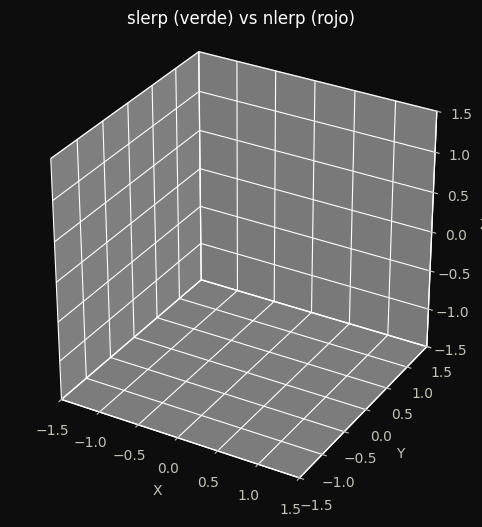

In [63]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 1])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("slerp (verde) vs nlerp (rojo)")


#### Eje de rotación

In [64]:
ax.plot([0, axis[0]], [0, axis[1]], [0, axis[2]],
        color="gray", linestyle="--", linewidth=1, label="Eje")

arrow_s = ax.plot([0, 0], [0, 0], [0, 1], color="#1baf7a", linewidth=3, label="slerp", zorder=5)[0]
arrow_n = ax.plot([0, 0], [0, 0], [0, 1], color="#e34948", linewidth=6, label="nlerp", zorder=1)[0]

ax.legend(loc="upper left")

def animate(frame):
    update_arrow(arrow_s, quat_to_rotmat(qs[frame]))
    update_arrow(arrow_n, quat_to_rotmat(qs_nlerp[frame]))
    return arrow_s, arrow_n

anim = FuncAnimation(fig, animate, frames=len(t_vals), interval=50, blit=False)


c:\Users\Julian Gomez\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [65]:
plt.rcParams["animation.html"] = "jshtml"
html = HTML(anim.to_jshtml())
plt.close(fig)
html


[09/23/26 16:49:49] INFO     Animation.save using <class 'matplotlib.animation.HTMLWriter'>       animation.py:1076

## Referencias

1. **Shoemake, Ken.** “Animating Rotation with Quaternion Curves”. *ACM SIGGRAPH Computer Graphics*, vol. 19, núm. 3, 1985, pp. 245–254.  
   DOI: [10.1145/325165.325242](https://doi.org/10.1145/325165.325242)

   Artículo original que introdujo `slerp` en gráficos por computadora.

2. **Documentación de Manim Community.**  
   [https://docs.manim.community/en/stable/](https://docs.manim.community/en/stable/)

   Biblioteca de animaciones matemáticas utilizada en las escenas de este notebook.

3. **SciPy — `scipy.spatial.transform.Rotation`.**  
   [https://docs.scipy.org/doc/scipy/reference/rotations.html](https://docs.scipy.org/doc/scipy/reference/rotations.html)

   Documentación de implementaciones robustas de cuaterniones, `slerp` y conversiones entre cuaterniones y matrices de rotación.
